# CNNs: An Introduction to Convolutional Neural Networks

*Materials were sourced from: [CNNs, Part 1: An Introduction to Convolutional Neural Networks - victorzhou.com](https://victorzhou.com/blog/intro-to-cnns-part-1/)*

There has been a lot of buzz about Convolution Neural Networks (CNNs) in recent years, especially for their impact on the field of Computer Vision. This notebook will provide an overview of CNNs, explain how they work, and guide you through building one from scratch using only NumPy in Python.


## 1. Motivation

A classic use case for CNNs is image classification, such as determining if an image contains a cat or a dog. But why not use a regular neural network?

### Reason 1: Images are Big
Modern images used in Computer Vision often have dimensions of 224x224 or more. For instance, a 224x224 color image with RGB channels has:

$$
224 \times 224 \times 3 = 150,528 \text{ input features}
$$

Training a neural network with these many features could lead to 150+ million weights for the first layer, making it massive and difficult to train.

### Reason 2: Positions Can Change
Networks should recognize objects regardless of their position within the image. A model trained on an image of a dog should still identify the dog if its position shifts slightly.


## 2. Dataset

Let's take the MNIST handwritten digit classification as an example. This dataset comprises 28x28 grayscale images of centered digits.
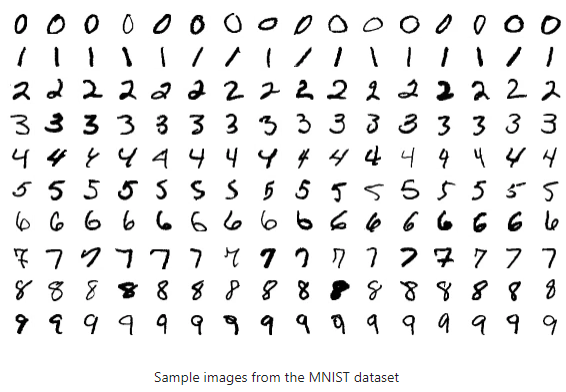



## 3. Convolutions

Convolutional Neural Networks (CNNs) incorporate convolutional layers that use filters (2D matrices) to process input images. Here is a typical 3x3 filter and how convolution works:

1. Perform element-wise multiplication between the filter and corresponding image values.
2. Sum the products to get the output value for a pixel.
3. Repeat for all pixel locations.

**Example of convolution:**

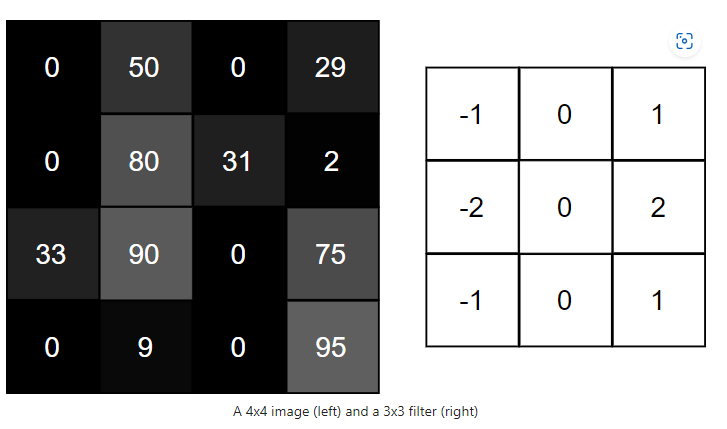
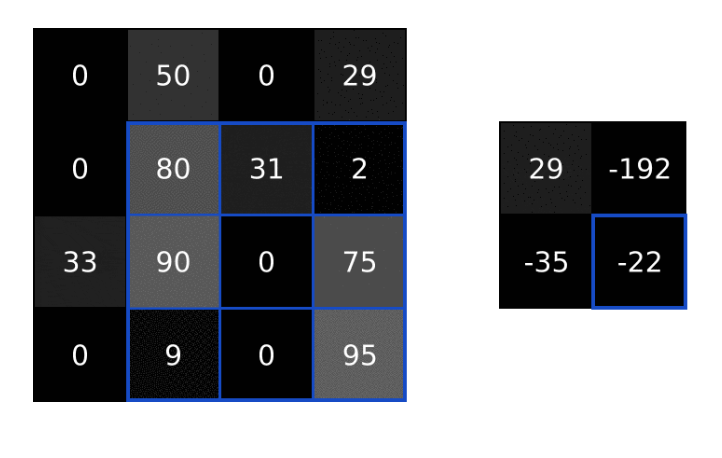

## 3.1 How is this useful?

Let’s zoom out for a second and see this at a higher level. What does convolving an image with a filter do? We can start by using the example 3x3 filter we’ve been using, which is commonly known as the vertical [Sobel filter](https://en.wikipedia.org/wiki/Sobel_operator):

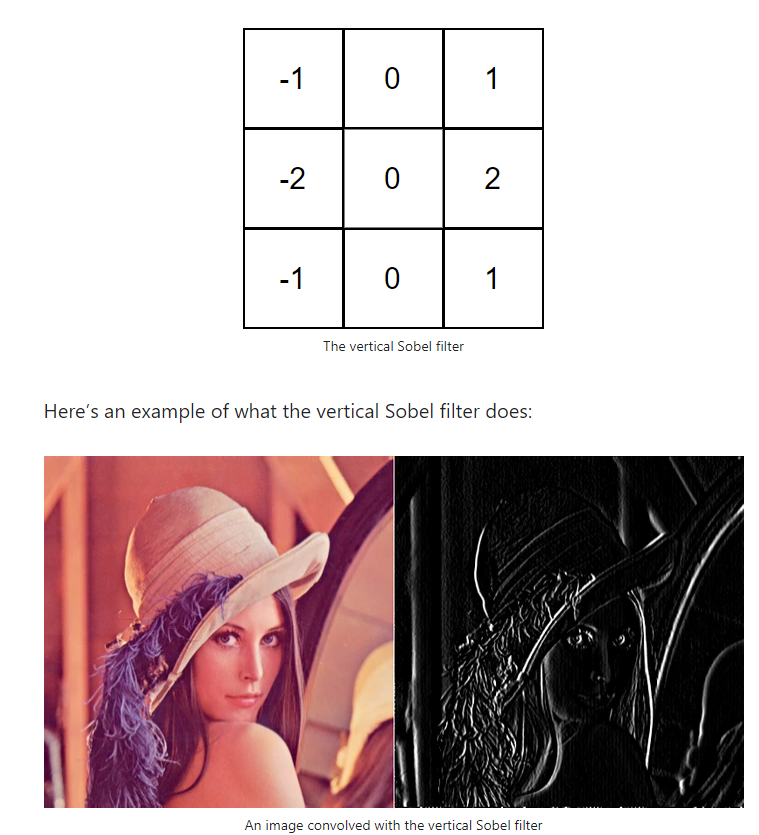


Similarly, there’s also a horizontal Sobel filter:

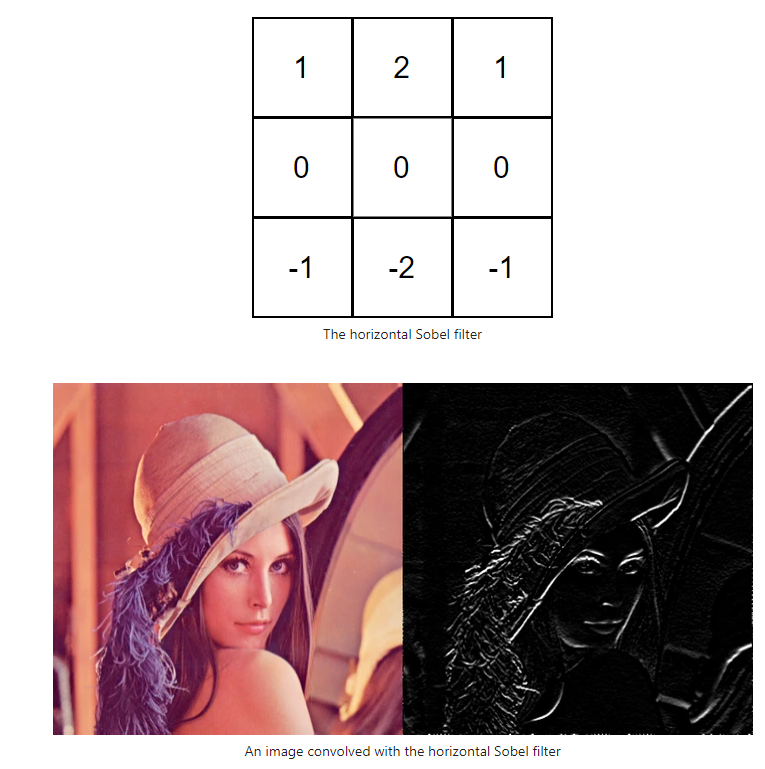

See what’s happening? **Sobel filters are edge-detectors.** The vertical Sobel filter detects vertical edges, and the horizontal Sobel filter detects horizontal edges. The output images are now easily interpreted: a bright pixel (one that has a high value) in the output image indicates that there’s a strong edge around there in the original image.

Can you see why an edge-detected image might be more useful than the raw image? Think back to our MNIST handwritten digit classification problem for a second. A CNN trained on MNIST might look for the digit 1, for example, by using an edge-detection filter and checking for two prominent vertical edges near the center of the image. In general, **convolution helps us look for specific localized image features** (like edges) that we can use later in the network.


### 3.2 Padding

Remember convolving a 4x4 input image with a 3x3 filter earlier to produce a 2x2 output image? Often, we’d prefer to have the output image be the same size as the input image. To do this, we add zeros around the image so we can overlay the filter in more places. A 3x3 filter requires 1 pixel of padding:

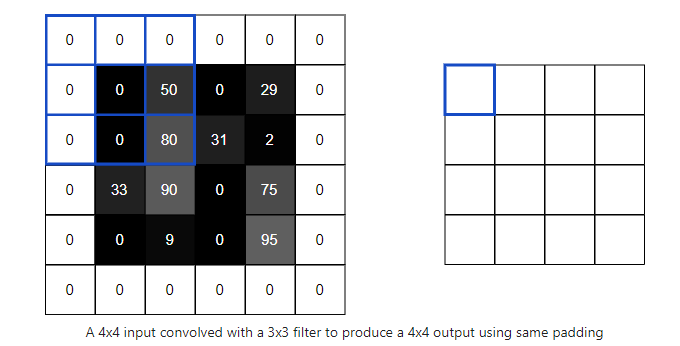



This is called **“same” padding**, since the input and output have the same dimensions. Not using any padding, which is what we’ve been doing and will continue to do for this post, is sometimes referred to as **“valid” padding**.


## 3.3 Conv Layers

Now that we know how image convolution works and why it’s useful, let’s see how it’s actually used in CNNs. As mentioned before, CNNs include **conv layers** that use a set of filters to turn input images into output images. A conv layer’s primary parameter is the **number of filters** it has.

For our MNIST CNN, we’ll use a small conv layer with 8 filters as the initial layer in our network. This means it’ll turn the 28x28 input image into a 26x26x8 output **volume**:

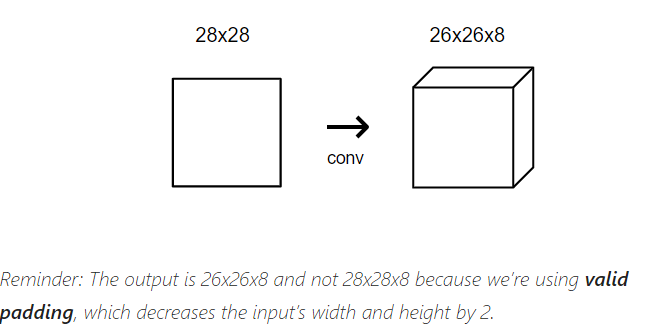

*Reminder: The output is 26x26x8 and not 28x28x8 because we’re using valid padding, which decreases the input’s width and height by 2.*

Each of the 8 filters in the conv layer produces a 26x26 output, so stacked together they make up a 26x26x8 volume. All of this happens because of:

$$
3 \times 3 \text{ (filter size)} \times 8 \text{ (number of filters)} = \text{only 72 weights!}
$$


## 4. Pooling

Neighboring pixels in images tend to have similar values, so conv layers will typically also produce similar values for neighboring pixels in outputs. As a result, **much of the information contained in a conv layer’s output is redundant.** For example, if we use an edge-detecting filter and find a strong edge at a certain location, chances are that we’ll also find relatively strong edges at locations 1 pixel shifted from the original one. However, **these are all the same edge!** We’re not finding anything new.

Pooling layers solve this problem. All they do is reduce the size of the input it’s given by (you guessed it) *pooling* values together in the input. The pooling is usually done by a simple operation like `max`, `min`, or `average`. Here’s an example of a Max Pooling layer with a pooling size of 2:

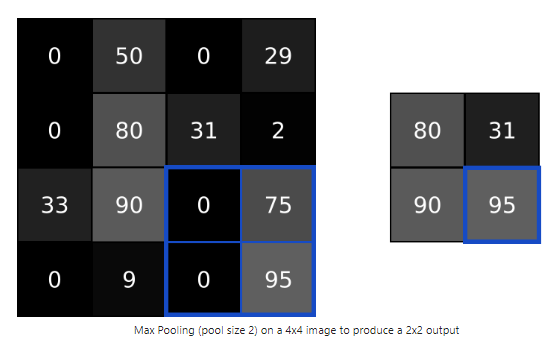

*Max Pooling (pool size 2) on a 4x4 image to produce a 2x2 output.*

To perform **max pooling**, we traverse the input image in 2x2 blocks (because pool size = 2) and put the max value into the output image at the corresponding pixel. That’s it!


Pooling divides the input’s width and height by the pool size. For our MNIST CNN, we’ll place a Max Pooling layer with a pool size of 2 right after our initial conv layer. The pooling layer will transform a 26x26x8 input into a 13x13x8 output:

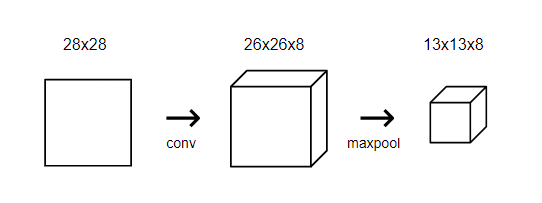

## 5. Softmax Layer

To complete our CNN, we need to give it the ability to actually make predictions. We’ll do that by using the standard final layer for a multiclass classification problem: the **Softmax** layer, a fully-connected (dense) layer that uses the [Softmax function](https://en.wikipedia.org/wiki/Softmax_function) as its activation.

> *Reminder*: Fully-connected layers have every node connected to every output from the previous layer. We used fully-connected layers in my [intro to Neural Networks](https://victorzhou.com/blog/intro-to-neural-networks/) if you need a refresher.

Softmax turns arbitrary real values into probabilities, which are often useful in Machine Learning. 



## 5.1 Usage

We’ll use a softmax layer with **10 nodes, one representing each digit**, as the final layer in our CNN. Each node in the layer will be connected to every input. After the softmax transformation is applied, **the digit represented by the node with the highest probability** will be the output of the CNN!

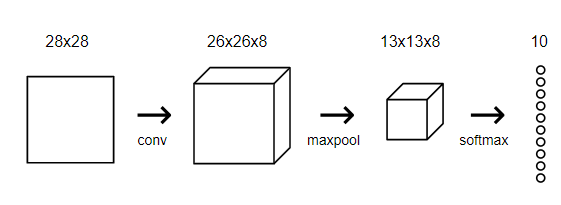

## 5.2 Cross-Entropy Loss

You might have just thought to yourself, *why bother transforming the outputs into probabilities? Won’t the highest output value always have the highest probability?* If you did, you’re absolutely right. **We don’t actually need to use softmax to predict a digit** – we could just pick the digit with the highest output from the network!

What softmax really does is help us **quantify how sure we are of our prediction**, which is useful when training and evaluating our CNN. More specifically, using softmax lets us use **cross-entropy loss**, which takes into account how sure we are of each prediction. Here’s how we calculate cross-entropy loss:

$$
L = -\ln(p_c)
$$

where $ c $ is the correct class (in our case, the correct digit), $ p_c $ is the predicted probability for class $ c $, and $ \ln $ is the [natural log](https://en.wikipedia.org/wiki/Natural_logarithm). As always, a lower loss is better. For example, in the best case, we’d have:

$$
p_c = 1, \quad L = -\ln(1) = 0
$$

In a more realistic case, we might have:

$$
p_c = 0.8, \quad L = -\ln(0.8) \approx 0.223
$$

We’ll be seeing cross-entropy loss again later on in this post, so keep it in mind!


## Implementing a Convolutional Neural Network:
### Example 1: The Problem: MNIST digit classification


train_images.shape:  (60000, 28, 28)
train_labels:  (60000,)
test_images.shape:  (10000, 28, 28)
test_labels:  (10000,)


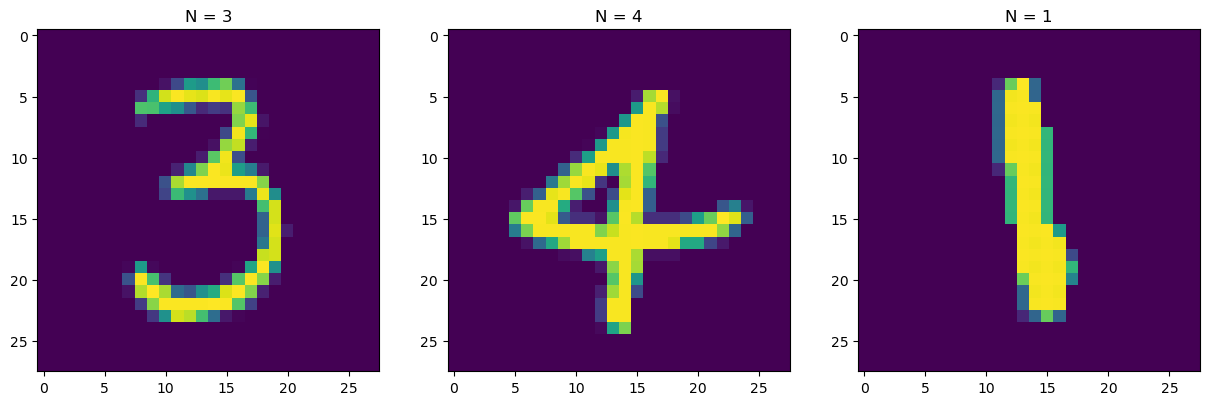

C:\ProgramData\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8522 - loss: 0.5247 - val_accuracy: 0.9116 - val_loss: 0.3096
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9103 - loss: 0.3068 - val_accuracy: 0.9219 - val_loss: 0.2739
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9196 - loss: 0.2769 - val_accuracy: 0.9289 - val_loss: 0.2542
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9271 - loss: 0.2537 - val_accuracy: 0.9328 - val_loss: 0.2317
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9332 - loss: 0.2326 - val_accuracy: 0.9385 - val_loss: 0.2193
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9389 - loss: 0.2137 - val_accuracy: 0.9417 - val_loss: 0.2007
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9443 - loss: 0.1970 - val_accuracy: 0.9476 - val_loss: 0.1823
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9480 - loss: 0

ValueError: The filename must end in `.weights.h5`. Received: filepath=cnn.h5

In [1]:


import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

#%% Preparing the Data --------------------------------------------------
#%% Load the MNIST dataset
mnist = keras.datasets.mnist
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

#%% Normalize the pixel values to be between 0 and 1
train_images = train_images / 255.0
test_images = test_images / 255.0

print('train_images.shape: ', train_images.shape)
print('train_labels: ', train_labels.shape)
print('test_images.shape: ', test_images.shape)
print('test_labels: ', test_labels.shape)

#%% 
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(train_images[50,:,:])
plt.title('N = {}'.format(train_labels[50]))

plt.subplot(1,3,2)
plt.imshow(train_images[150,:,:])
plt.title('N = {}'.format(train_labels[150]))

plt.subplot(1,3,3)
plt.imshow(train_images[200,:,:])
plt.title('N = {}'.format(train_labels[200]))
plt.show()


#-------------------------------------------------------------------------
#%% Building the Model ---------------------------------------------------
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten

num_filters = 8
filter_size = 3
pool_size = 2

# We’ll use 3 types of layers for our CNN: Convolutional, Max Pooling, 
# and Softmax.
model = Sequential([
  Conv2D(num_filters, filter_size, input_shape=(28, 28, 1)),
  MaxPooling2D(pool_size=pool_size),
  Flatten(),
  Dense(10, activation='softmax'),
])

#  Compiling the Model
model.compile(
  'SGD', # Stochastic gradient descent
  loss='categorical_crossentropy',
  metrics=['accuracy'],
)

#-------------------------------------------------------------------------
#%%   Training the Model  ------------------------------------------------
from tensorflow.keras.utils import to_categorical
model.fit(
  train_images,
  to_categorical(train_labels),
  epochs=10,
  validation_data=(test_images, to_categorical(test_labels)),
)

model.save_weights('cnn.h5')

#-------------------------------------------------------------------------
#%% Using the model       ------------------------------------------------
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten

num_filters = 8
filter_size = 3
pool_size = 2

# Build the model.
model = Sequential([
  Conv2D(num_filters, filter_size, input_shape=(28, 28, 1)),
  MaxPooling2D(pool_size=pool_size),
  Flatten(),
  Dense(10, activation='softmax'),
])

# Load the model's saved weights.
model.load_weights('cnn.h5')


# Predict on the first 5 test images.
predictions = model.predict(test_images[:5])

# Print our model's predictions.
print(np.argmax(predictions, axis=1)) # [7, 2, 1, 0, 4]

# Check our predictions against the ground truths.
print(test_labels[:5]) # [7, 2, 1, 0, 4]












